In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing # 导入加州房价数据集
from sklearn.model_selection import train_test_split # 导入训练集测试集划分函数
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # 导入评价指标



In [51]:
#线性回归模型类
class LinearRegression:
    def __init__(self):
        self.theta = None

    def fit(self, X, Y):
        """
        训练模型
        :param X: 输入特征矩阵
        :param Y: 输出目标向量
        :return: None
        """
        n_samples = X.shape[0]
        X_b = np.hstack((np.ones((n_samples, 1)), X))

        self.theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ Y

    def predict(self, X):
        """预测函数"""
        X_b = np.hstack([np.ones((X.shape[0], 1)), X])
        return X_b @ self.theta #矩阵乘法，得到预测值


In [52]:
# 倒入加州房价数据集
housing = fetch_california_housing()
X = housing.data
Y = housing.target
# print(housing.data, housing.target,housing.DESCR)
# print(X.shape, Y.shape)
# print(housing.feature_names)

In [53]:
# 划分训练集测试集
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [54]:
# 训练
model = LinearRegression()
model.fit(X_train, Y_train)


In [ ]:
_pred = model.predict(X_test)

In [56]:
# 评估指标 这个部分不懂 直接抄的
mae_r = mean_absolute_error(Y_test, y_pred)
mse_r = mean_squared_error(Y_test, y_pred)
rmse_r = np.sqrt(mse_r)
r2_r = r2_score(Y_test, y_pred)

print("="*50)
print("线性回归 评估指标")
print("="*50)
print(f"平均绝对误差 (MAE)：{mae_r:.4f}")
print(f"均方误差 (MSE)：{mse_r:.4f}")
print(f"均方根误差 (RMSE)：{rmse_r:.4f}")
print(f"决定系数 (R²)：{r2_r:.4f}")
print("="*50)

线性回归 评估指标
平均绝对误差 (MAE)：0.5332
均方误差 (MSE)：0.5559
均方根误差 (RMSE)：0.7456
决定系数 (R²)：0.5758


/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from current font.
  fig.canvas.print_figure(b

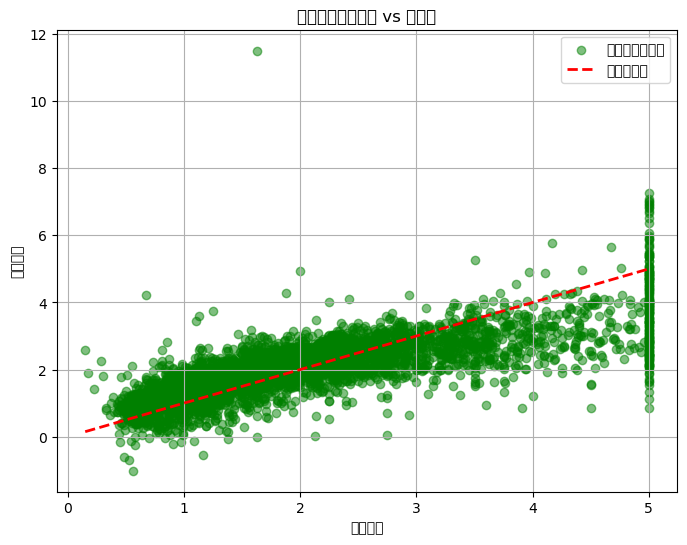

In [57]:
# 结果可视化 也是直接抄的 不懂
plt.figure(figsize=(8, 6))
plt.scatter(Y_test, Y_pred, alpha=0.5, color="green", label="线性回归预测值")
plt.plot([Y.min(), Y.max()], [Y.min(), Y.max()], "r--", lw=2, label="理想拟合线")
plt.xlabel("真实房价")
plt.ylabel("预测房价")
plt.title("线性回归：真实值 vs 预测值")
plt.legend()
plt.grid(True)
plt.show()